In [1]:
import os
from pathlib import Path
import torch
import sys

# Add project root to sys.path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from material_aware_flare.eval import extract_flare_channels
from material_aware_flare.utils import save_extracted_channels

# Select the device
device = torch.device('cpu')
devices = 0
if torch.cuda.is_available() and devices >= 0:
    device = torch.device(f'cuda:{devices}')

flame_path = "/home/hleonhard/adl4cv_ws25-26_Relightable-Avatars/external/flare_adl4cv/flame/FLAME2020/generic_model.pkl"

In [2]:
!gcc --version  # MUST show gcc-11
!g++ --version
!nvcc --version  # shows CUDA 12.0, that is fine now


gcc (Ubuntu 11.5.0-1ubuntu1~24.04) 11.5.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

g++ (Ubuntu 11.5.0-1ubuntu1~24.04) 11.5.0
Copyright (C) 2021 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Tue_Mar__8_18:18:20_PST_2022
Cuda compilation tools, release 11.6, V11.6.124
Build cuda_11.6.r11.6/compiler.31057947_0


In [3]:
import sys
sys.path.append("../external/flare_adl4cv") 
from flame.FLAME import FLAME
from flare.core import (
    Mesh, Renderer
)
from flare.modules import (
    NeuralShader, get_deformer_network
)
from flare.utils import (
    AABB, read_mesh,
    save_individual_img, make_dirs, save_relit_intrinsic_materials
)
import nvdiffrec.render.light as light
from flare.dataset import DatasetLoader
from flare.dataset import dataset_util
from flare.metrics import metrics

from arguments import config_parser


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/hleonhard/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [4]:
config = {
    'config': None,
    # run_name
    'run_name': '001',
    # batch_size
    'batch_size': 2,
    # path
    'input_dir': Path("/home/hleonhard/data/flare_subject_data/001"),
    'train_dir': ["MVI_1810", "MVI_1811", "MVI_1812"],
    'eval_dir': ["MVI_1814"],
    'working_dir': Path("/home/hleonhard/data/flare_models/"),
    'output_dir': Path("/home/hleonhard/data/flare_models"),
    # misc
    'sample_idx_ratio': 1,
    'device': 0,
    'finetune_color': False,
    # iters
    'iterations': 2000, 
    'final_iter': 1500,
    'upsample_iterations': [500],
    'save_frequency': 300,
    'visualization_frequency': 100,
    'visualization_views': [15, 25, 27, 21, 26],
    # 'downsample' default is set via set_defaults
    'downsample': False,
    'downsample_ratio': 0.03,
    'grad_scale': False, # Default for action='store_true' is False unless set otherwise
    # flame
    'decay_flame': [100],
    'flame_mask': False,
    # lr
    'lr_vertices': 1e-3,
    'lr_shader': 1e-3,
    'lr_deformer': 1e-3,
    # loss weights
    'weight_mask': 2.0,
    'weight_normal': 0.1,
    'weight_laplacian': 60.0,
    'weight_shading': 1.0,
    'weight_perceptual_loss': 0.1,
    'weight_albedo_regularization': 0.01,
    'weight_flame_regularization': 10.0,
    'weight_white_lgt_regularization': 1.0,
    'weight_roughness_regularization': 0.1,
    'weight_fresnel_coeff': 0.01,
    'r_mean': 0.500,
    # neural shader
    'fourier_features': 'positional',
    'activation': 'relu',
    'bsdf': 'pbr_shading',
    'deform_d_out': 128,
    'light_mlp_ch': 3,
    'light_mlp_dims': [64, 64],
    'material_mlp_dims': [128, 128, 128, 128],
    'material_mlp_ch': 4,
    # ghostbone/train_deformer (defaults are set via set_defaults)
    'ghostbone': True,
    'train_deformer': True,
    'deform_dims': [128, 128, 128, 128]
}


subject = 1

new_values_1 = {
    'run_name': '001',
    'input_dir': Path("/home/hleonhard/data/flare_subject_data/001"),
    'train_dir': ["MVI_1810", "MVI_1811", "MVI_1812"],
    'eval_dir': ["MVI_1814"],
    'working_dir': Path("/home/hleonhard/data/flare_models/"),
    'output_dir': Path("/home/hleonhard/data/flare_models/001"),
    'batch_size': 1,
    'sample_idx_ratio': 1,
    'iterations': 1500,
    'upsample_iterations': [500],
    'lr_deformer': 1e-3,
    'lr_shader': 1e-3,
    'lr_vertices': 1e-3,
    'weight_shading': 1.0,
    'weight_perceptual_loss': 0.1,
    'weight_mask': 2.0,
    'weight_albedo_regularization': 0.01,
    'weight_white_lgt_regularization': 0.01,
    'weight_roughness_regularization': 0.01,
    'weight_fresnel_coeff': 0.01,
    'weight_normal': 0.1,
    'weight_laplacian': 60.0,
    'light_mlp_ch': 3,
    'light_mlp_dims': [64, 64],
    'material_mlp_dims': [128, 128, 128, 128],
    'material_mlp_ch': 5
}

if subject == 1:
  config.update(new_values_1)

from types import SimpleNamespace
config = SimpleNamespace(**config)

In [5]:
images_save_path, images_eval_save_path, meshes_save_path, shaders_save_path, experiment_dir = make_dirs(
    config, config.run_name, config.finetune_color
  )
dataset_val = DatasetLoader(config, train_dir=config.eval_dir, sample_ratio=config.sample_idx_ratio, pre_load=False)
dataloader_validate = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate, shuffle=False)

In [6]:
flame_shape = dataset_val.shape_params
FLAMEServer = FLAME(flame_path, n_shape=100, n_exp=50, shape_params=flame_shape).to(device)

creating the FLAME Decoder


In [7]:
### Obtain the initial mesh and compute its connectivity
flame_canonical_mesh = Mesh(FLAMEServer.v_template, FLAMEServer.faces_tensor, device=device)
flame_canonical_mesh.compute_connectivity()
### create bounding box from the mesh vertices
aabb = AABB(flame_canonical_mesh.vertices.cpu().numpy())
flame_mesh_aabb = [torch.min(flame_canonical_mesh.vertices, dim=0).values, torch.max(flame_canonical_mesh.vertices, dim=0).values]
# init mesh is mouth open!!!
FLAMEServer.canonical_exp = dataset_val.get_mean_expression_train(config.train_dir).to(device)
FLAMEServer.canonical_pose = FLAMEServer.canonical_pose.to(device)
FLAMEServer.canonical_verts, FLAMEServer.canonical_pose_feature, FLAMEServer.canonical_transformations = \
    FLAMEServer(expression_params=FLAMEServer.canonical_exp, full_pose=FLAMEServer.canonical_pose)
FLAMEServer.canonical_verts = FLAMEServer.canonical_verts.to(device)
flame_canonical_mesh.vertices = FLAMEServer.canonical_verts.squeeze(0)

In [8]:
experiment_dir = Path('/home/hleonhard/data/flare_models/001')

In [9]:
# ==============================================================================================
# mesh
# ==============================================================================================
mesh_path = Path(experiment_dir / "stage_1" / "meshes" / f"mesh_latest.obj")
mesh = read_mesh(mesh_path, device=device)
mesh.compute_connectivity()
mesh.to(device)

In [10]:
# ==============================================================================================
# Rendererrr
# ==============================================================================================
renderer = Renderer(device=device)
renderer.set_near_far(dataset_val, torch.from_numpy(aabb.corners).to(device), epsilon=0.5)
channels_gbuffer = ['mask', 'position', 'normal', "canonical_position"]

In [11]:
# ==============================================================================================
# deformation
# ==============================================================================================
load_deformer = Path(experiment_dir / "stage_2" / "network_weights" / f"deformer_latest.pt")
assert os.path.exists(load_deformer)
multires = 0
deformer_net = get_deformer_network(FLAMEServer, model_path=load_deformer, train=False, d_in=3, dims=[128, 128, 128, 128],
                                       weight_norm=True, multires=multires, num_exp=50, aabb=aabb, ghostbone=config.ghostbone, device=device)
if config.ghostbone:
    FLAMEServer.canonical_transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).float().to(device), FLAMEServer.canonical_transformations], 1)

In [12]:
# ==============================================================================================
# shading
# ==============================================================================================
load_shader = Path(experiment_dir / "stage_2" / "network_weights" / f"shader_latest.pt")
assert os.path.exists(load_shader)
shader = NeuralShader.load(load_shader, device=device)
lgt = light.create_env_rnd()
print("=="*50)
shader.eval()
deformer_net.eval()
batch_size = config.batch_size
print("Batch Size:", batch_size)

STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}
Batch Size: 1


In [13]:
# ==============================================================================================
# evaluation
# ==============================================================================================
def run(
    args,
    mesh,
    views,
    FLAMEServer,
    deformer_net,
    shader,
    renderer,
    device,
    channels_gbuffer,
    lgt,
):
    ## ============== deform ==============================
    shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
    eval_vertices = mesh.vertices
    batched_verts = eval_vertices.unsqueeze(0).repeat(views["img"].shape[0], 1, 1)

    _, pose_features, transformations = FLAMEServer(
        expression_params=views["flame_expression"], full_pose=views["flame_pose"]
    )
    if args.ghostbone:
        transformations = torch.cat(
            [
                torch.eye(4)
                .unsqueeze(0)
                .unsqueeze(0)
                .expand(views["img"].shape[0], -1, -1, -1)
                .float()
                .to(device),
                transformations,
            ],
            1,
        )
    deformed_vertices = FLAMEServer.forward_pts_batch(
        pnts_c=batched_verts,
        betas=views["flame_expression"],
        transformations=transformations,
        pose_feature=pose_features,
        shapedirs=shapedirs,
        posedirs=posedirs,
        lbs_weights=lbs_weights,
        dtype=torch.float32,
        map2_flame_original=True,
    )

    d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
    ## ============== Rasterize ==============================
    gbuffers = renderer.render_batch(
        views["camera"],
        deformed_vertices.contiguous(),
        d_normals,
        channels=channels_gbuffer,
        with_antialiasing=True,
        canonical_v=mesh.vertices,
        canonical_idx=mesh.indices,
    )

    ## ============== predict color ==============================
    rgb_pred, cbuffers, gbuffer_mask = shader.shade(
        gbuffers, views, mesh, args.finetune_color, lgt
    )

    return rgb_pred, gbuffers, cbuffers


# ==============================================================================================
# relight: run
# ==============================================================================================
def run_relight(
    args,
    mesh,
    views,
    FLAMEServer,
    deformer_net,
    shader,
    renderer,
    device,
    channels_gbuffer,
    lgt_list,
    images_save_path,
):
    ## ============== deform ==============================
    shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
    eval_vertices = mesh.vertices
    batched_verts = eval_vertices.unsqueeze(0).repeat(views["img"].shape[0], 1, 1)

    _, pose_features, transformations = FLAMEServer(
        expression_params=views["flame_expression"], full_pose=views["flame_pose"]
    )
    if args.ghostbone:
        transformations = torch.cat(
            [
                torch.eye(4)
                .unsqueeze(0)
                .unsqueeze(0)
                .expand(views["img"].shape[0], -1, -1, -1)
                .float()
                .to(device),
                transformations,
            ],
            1,
        )
    deformed_vertices = FLAMEServer.forward_pts_batch(
        pnts_c=batched_verts,
        betas=views["flame_expression"],
        transformations=transformations,
        pose_feature=pose_features,
        shapedirs=shapedirs,
        posedirs=posedirs,
        lbs_weights=lbs_weights,
        dtype=torch.float32,
        map2_flame_original=True,
    )

    d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
    ## ============== Rasterize ==============================
    gbuffers = renderer.render_batch(
        views["camera"],
        deformed_vertices.contiguous(),
        d_normals,
        channels=channels_gbuffer,
        with_antialiasing=True,
        canonical_v=mesh.vertices,
        canonical_idx=mesh.indices,
    )

    ## ============== predict color ==============================
    relit_imgs, cbuffers, gbuffer_mask = shader.relight(
        gbuffers, views, mesh, args.finetune_color, lgt_list
    )
    save_relit_intrinsic_materials(
        relit_imgs, views, gbuffer_mask, cbuffers, images_save_path
    )

In [ ]:
# import shutil
# import os
# 
# cache_dir = os.path.expanduser("~/.cache/torch_extensions")
# print("Removing:", cache_dir)
# shutil.rmtree(cache_dir, ignore_errors=True)

Removing: /home/hleonhard/.cache/torch_extensions


In [14]:
def quantitative_eval_flare(
    args,
    mesh,
    dataloader_validate,
    FLAMEServer,
    deformer_net,
    shader,
    renderer,
    device,
    channels_gbuffer,
    experiment_dir,
    images_eval_save_path,
    lgt=None,
    save_each=False,
):

    for it, views_subset in enumerate(dataloader_validate):
        with torch.no_grad():
            rgb_pred, gbuffer, cbuffer = run(
                args,
                mesh,
                views_subset,
                FLAMEServer,
                deformer_net,
                shader,
                renderer,
                device,
                channels_gbuffer,
                lgt=lgt,
            )
            extracted_channels = extract_flare_channels(
                shader, gbuffer, views_subset, mesh
            )
            print(f"extracted channels")
            break
        save_extracted_channels(
            extracted_channels, views_subset["img_idx"], images_eval_save_path
        )
        rgb_pred = rgb_pred * gbuffer["mask"]

In [37]:
from tqdm.notebook import tqdm


for it, views_subset in tqdm(enumerate(dataloader_validate), total=len(dataloader_validate)):
    with torch.no_grad():
        rgb_pred, gbuffer, cbuffer = run(
            config,
            mesh,
            views_subset,
            FLAMEServer,
            deformer_net,
            shader,
            renderer,
            device,
            channels_gbuffer,
            lgt=lgt,
        )
        extracted_channels = extract_flare_channels(
            shader, gbuffer, views_subset, mesh
        )
    save_extracted_channels(
        extracted_channels, views_subset["idx"], images_eval_save_path
    )
    rgb_pred = rgb_pred * gbuffer["mask"]


  0%|          | 0/428 [00:00<?, ?it/s]

In [38]:
!ls /home/hleonhard/data/flare_models/001/001/images_evaluation/albedo

0000.png  0214.png  0428.png  0642.png	0856.png  1070.png  1284.png  1498.png
0001.png  0215.png  0429.png  0643.png	0857.png  1071.png  1285.png  1499.png
0002.png  0216.png  0430.png  0644.png	0858.png  1072.png  1286.png  1500.png
0003.png  0217.png  0431.png  0645.png	0859.png  1073.png  1287.png  1501.png
0004.png  0218.png  0432.png  0646.png	0860.png  1074.png  1288.png  1502.png
0005.png  0219.png  0433.png  0647.png	0861.png  1075.png  1289.png  1503.png
0006.png  0220.png  0434.png  0648.png	0862.png  1076.png  1290.png  1504.png
0007.png  0221.png  0435.png  0649.png	0863.png  1077.png  1291.png  1505.png
0008.png  0222.png  0436.png  0650.png	0864.png  1078.png  1292.png  1506.png
0009.png  0223.png  0437.png  0651.png	0865.png  1079.png  1293.png  1507.png
0010.png  0224.png  0438.png  0652.png	0866.png  1080.png  1294.png  1508.png
0011.png  0225.png  0439.png  0653.png	0867.png  1081.png  1295.png  1509.png
0012.png  0226.png  0440.png  0654.png	0868.png  1082.png  1296.

In [22]:
extracted_channels.keys()

dict_keys(['albedo', 'normal', 'roughness', 'irradiance', 'specular_intensity'])

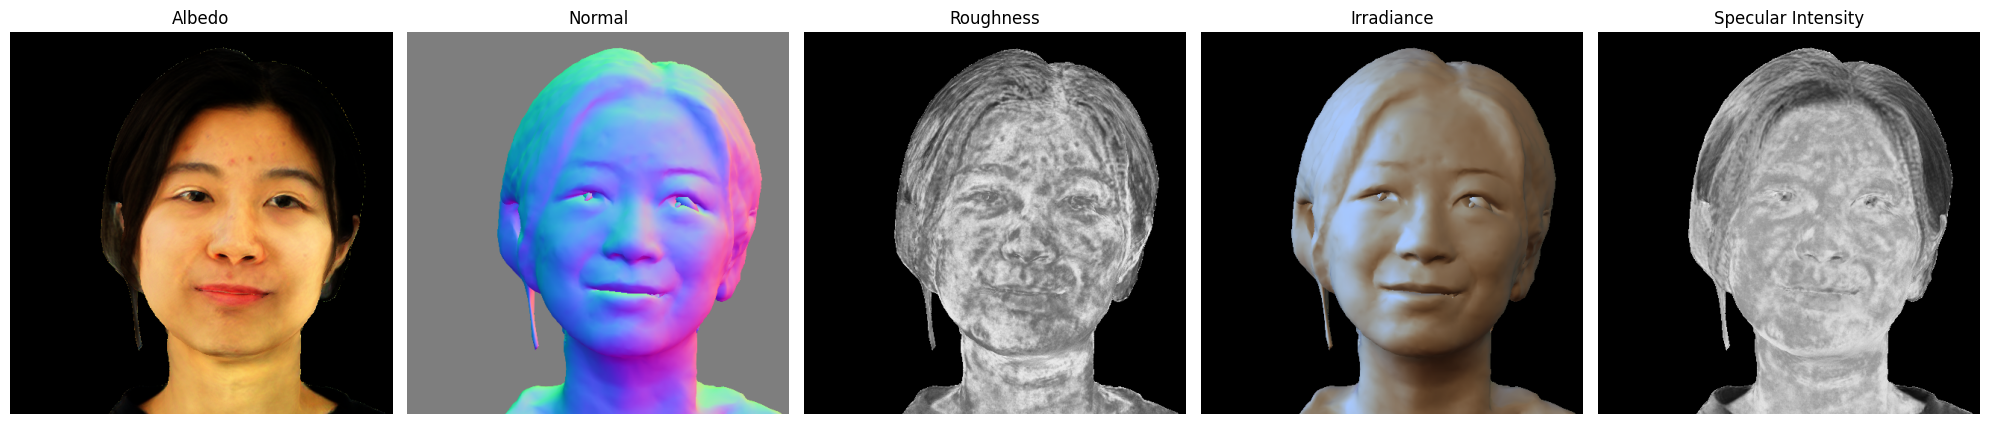

In [24]:
import torch
import matplotlib.pyplot as plt

def tensor_to_numpy(img):
    """img: (H, W, C) tensor in [0,1] or any range. Returns uint8 numpy."""
    img = img.detach().cpu()
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]

    # Normalize each channel independently for visualization if needed
    img_min, img_max = img.min(), img.max()
    if (img_max - img_min) > 1e-6:
        img = (img - img_min) / (img_max - img_min)

    img = (img * 255).clamp(0, 255).byte().numpy()
    return img


def plot_flare_channels(extracted):
    """
    extracted: dict returned by extract_flare_channels()
               each entry is (B, H, W, C)
    """

    # use first batch element B=0
    albedo = extracted["albedo"][0]          # (H,W,3)
    normal = extracted["normal"][0]          # (H,W,3)
    rough  = extracted["roughness"][0]       # (H,W,1)
    irr    = extracted["irradiance"][0]      # (H,W,3)
    spec   = extracted["specular_intensity"][0]  # (H,W,1)

    # Convert all to numpy for plotting
    albedo_np = tensor_to_numpy(albedo)
    normal_np = tensor_to_numpy(normal)
    rough_np  = tensor_to_numpy(rough)
    irr_np    = tensor_to_numpy(irr)
    spec_np   = tensor_to_numpy(spec)

    # Build figure
    fig, axs = plt.subplots(1, 5, figsize=(20, 5))

    axs[0].imshow(albedo_np)
    axs[0].set_title("Albedo")
    axs[0].axis('off')

    axs[1].imshow(normal_np)
    axs[1].set_title("Normal")
    axs[1].axis('off')

    axs[2].imshow(rough_np, cmap="gray")
    axs[2].set_title("Roughness")
    axs[2].axis('off')

    axs[3].imshow(irr_np)
    axs[3].set_title("Irradiance")
    axs[3].axis('off')

    axs[4].imshow(spec_np, cmap="gray")
    axs[4].set_title("Specular Intensity")
    axs[4].axis('off')

    plt.tight_layout()
    plt.show()

plot_flare_channels(extracted_channels)

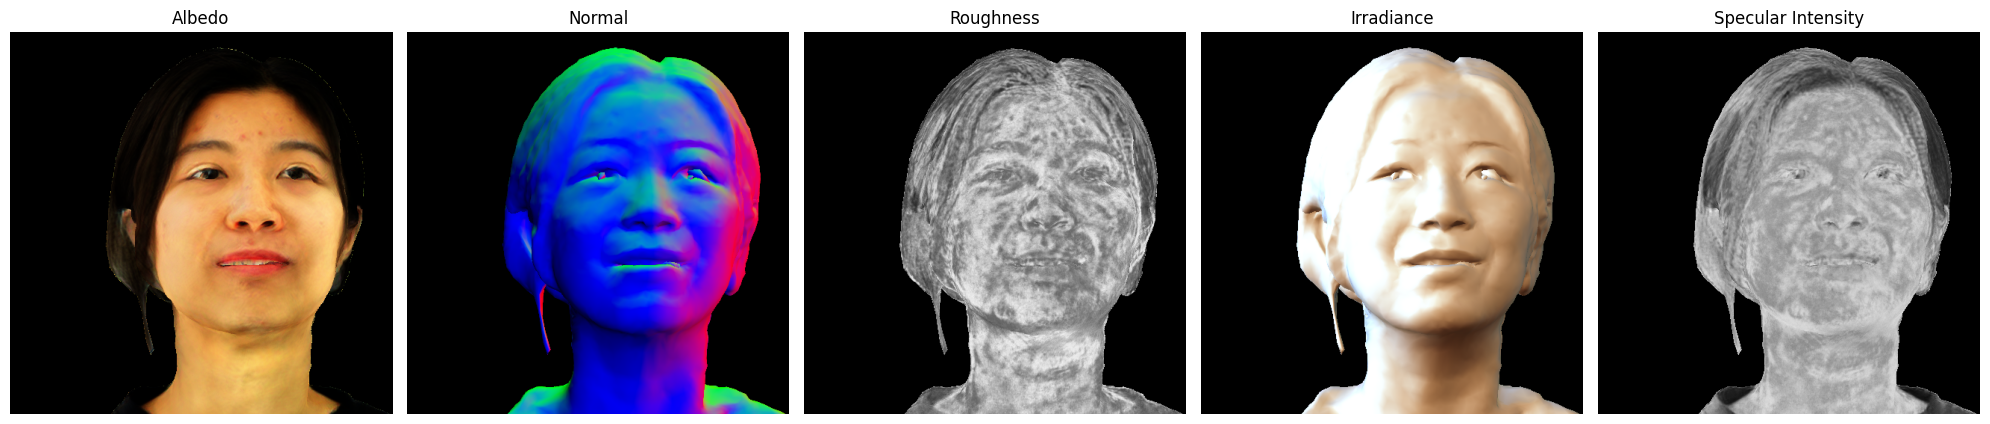

In [39]:
import matplotlib.pyplot as plt

img1 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/albedo/0660.png')
img2 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/normal/0660.png')
img3 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/roughness/0660.png')
img4 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/irradiance/0660.png')
img5 = plt.imread('/home/hleonhard/data/flare_models/001/001/images_evaluation/specular_intensity/0660.png')

fig, axs = plt.subplots(1, 5, figsize=(20, 5))
axs[0].imshow(img1)
axs[0].set_title("Albedo")
axs[0].axis('off')
axs[1].imshow(img2)
axs[1].set_title("Normal")
axs[1].axis('off')
axs[2].imshow(img3, cmap="gray")
axs[2].set_title("Roughness")
axs[2].axis('off')
axs[3].imshow(img4)
axs[3].set_title("Irradiance")
axs[3].axis('off')
axs[4].imshow(img5, cmap="gray")
axs[4].set_title("Specular Intensity")
axs[4].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ==============================================================================================
# evaluation: intrinsic materials and relighting
# ==============================================================================================
lgt_list = light.load_target_cubemaps(config.working_dir)
for i in range(len(lgt_list)):
    Path(images_eval_save_path / "qualitative_results" / f"env_map_{i}" ).mkdir(parents=True, exist_ok=True)
for it, views_subset in enumerate(dataloader_validate):
    with torch.no_grad():
        quantitative_eval_flare(config, mesh, views_subset, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt_list, images_eval_save_path / "qualitative_results")
        # run_relight(config, mesh, views_subset, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt_list, images_eval_save_path / "qualitative_results")

In [ ]:
def quantitative_eval_flare(
    args,
    mesh,
    dataloader_validate,
    FLAMEServer,
    deformer_net,
    shader,
    renderer,
    device,
    channels_gbuffer,
    experiment_dir,
    images_eval_save_path,
    lgt=None,
    save_each=False,
):

    for it, views_subset in enumerate(dataloader_validate):
        with torch.no_grad():
            rgb_pred, gbuffer, cbuffer = run(
                args,
                mesh,
                views_subset,
                FLAMEServer,
                deformer_net,
                shader,
                renderer,
                device,
                channels_gbuffer,
                lgt=lgt,
            )
            extracted_channels = extract_flare_channels(
                shader, gbuffer, views_subset, mesh
            )
        save_extracted_channels(
            extracted_channels, views_subset["img_idx"], images_eval_save_path
        )
        rgb_pred = rgb_pred * gbuffer["mask"]